# Yolo

Doc : https://docs.ultralytics.com/tasks/pose

## TLDR

In [6]:
from ultralytics import YOLO
import pandas as pd
import cv2

model = YOLO("yolo26n-pose.pt")
result = model("../assets/backflip.mov", save=True)


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/119) c:\Users\esteb\BackflipAnalysis\computer_vision\..\assets\backflip.mov: 640x384 1 person, 25.2ms
video 1/1 (frame 2/119) c:\Users\esteb\BackflipAnalysis\computer_vision\..\assets\backflip.mov: 640x384 1 person, 26.9ms
video 1/1 (frame 3/119) c:\Users\esteb\BackflipAnalysis\computer_vision\..\assets\backflip.mov: 640x384 1 person, 27.0ms
video 1/1 (frame 4/119) c:\Users\esteb\BackflipAnalysis\computer_vision\..\assets\backflip.mov: 640

Here, result is composed of a Results object by frame. Each Results contains a bunch of stuff such as:  </br>

- orig_img: original image represented as a numpy array.
- orig_shape: shape of the original image.
- path
- names: yolo is pretrained to detect people so those are the names of the classes.
- boxes: coordinates of the bounding boxes around people detected by the model.
- keypoints: tensor of coordinates.

In keypoints, each tensor contains the keypoint coordinates for one frame, with each vector representing a specific body joint.

| Index | Keypoint |
|---:|---|
| 0 | nose |
| 1 | left_eye |
| 2 | right_eye |
| 3 | left_ear |
| 4 | right_ear |
| 5 | left_shoulder |
| 6 | right_shoulder |
| 7 | left_elbow |
| 8 | right_elbow |
| 9 | left_wrist |
| 10 | right_wrist |
| 11 | left_hip |
| 12 | right_hip |
| 13 | left_knee |
| 14 | right_knee |
| 15 | left_ankle |
| 16 | right_ankle |

In [7]:
result[0].keypoints.xy

tensor([[[ 645.6093,  487.5616],
         [ 649.0063,  473.1666],
         [ 638.5749,  470.9119],
         [ 615.1785,  464.1778],
         [ 596.5909,  458.2012],
         [ 568.0853,  524.0497],
         [ 570.7501,  511.0434],
         [ 651.4137,  591.2513],
         [ 677.8850,  565.3253],
         [ 771.4835,  575.4571],
         [ 800.7443,  548.5785],
         [ 553.3489,  745.9801],
         [ 549.2734,  743.0568],
         [ 556.8082,  926.9130],
         [ 560.4792,  928.9406],
         [ 532.1731, 1102.3199],
         [ 533.4520, 1118.6290]]])

## From .mp4 to pandas df

In [8]:
# get fps number
cap = cv2.VideoCapture("../assets/backflip.mov")
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()

In [9]:
KEYPOINTS = ["nose","left_eye","right_eye","left_ear","right_ear","left_shoulder","right_shoulder","left_elbow","right_elbow","left_wrist","right_wrist","left_hip","right_hip","left_knee","right_knee","left_ankle","right_ankle"]
rows = []

# Itering over each frames
for frame_index, result in enumerate(result):

    # a keypoint is a vector of coordinates, for example the coordinates of your nose at said frame
    # no keypoint means no one detected on the frame so we move on to the next frame
    if len(result.keypoints) == 0:
        continue

    points = result.keypoints.xyn[0].cpu().numpy() # xyn coordinates are normalized meaning they take into consideration the size of the image
    conf = result.keypoints.conf[0].cpu().numpy() # confidence

    # Itering over each keypoints for a frame
    for i, name in enumerate(KEYPOINTS):

        rows.append({
            "frame":frame_index,
            "time": frame_index / fps,
            "keypoint": name,
            "x": points[i][0],
            "y": points[i][1],
            "confidence": conf[i]
        })


df = pd.DataFrame(rows)
print(df.shape)
display(df.head(30))

(2023, 6)


,frame,time,keypoint,x,y,confidence
0,0,0.000000,nose,0.597786,0.253938,0.975127
1,0,0.000000,left_eye,0.600932,0.246441,0.225195
2,0,0.000000,right_eye,0.591273,0.245267,0.991698
3,0,0.000000,left_ear,0.569610,0.241759,0.009611
4,0,0.000000,right_ear,0.552399,0.238646,0.985843
5,0,0.000000,left_shoulder,0.526005,0.272943,0.945839
6,0,0.000000,right_shoulder,0.528472,0.266168,0.997357
7,0,0.000000,left_elbow,0.603161,0.307943,0.657381
8,0,0.000000,right_elbow,0.627671,0.294440,0.995105
9,0,0.000000,left_wrist,0.714337,0.299717,0.803789


In [13]:
print("N frames :", df["frame"].nunique())
print("N keypoints :", df["keypoint"].nunique())
print("Length :", df["time"].max())

N frames : 119
N keypoints : 17
Length : 1.965014005602241


## Visualization

Now that we have the data frame we can visualize it through time. Below an example of the trajectory of the right hip.
</br>
Remember that in computer vision, (0,0) is at the top left, so to go down we increase y. Meaning that when y increases, the hip goes down in the image.

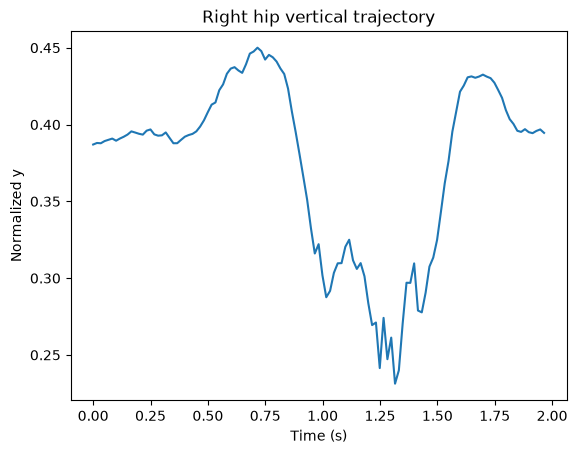

In [16]:
import matplotlib.pyplot as plt

hip = df[df["keypoint"] == "right_hip"]

plt.plot(hip["time"], hip["y"])
plt.xlabel("Time (s)")
plt.ylabel("Normalized y")
plt.title("Right hip vertical trajectory")
plt.show()